## Now simulate full SNIa population in a cluster.
Refer to <code>script_instructions.txt</code> for instructions on how to submit a population simulation

We have tested the simulations with a smaller population. Using R_z , we can expect to have 11299884 SNIa within $z \in [10^{-4}, 1.0]$ for whole sky (dec_range $\in$ [-90, 90]) for 1 yr + 100 days,
and 91139849 SNIa for 10 yrs + 100 days

#### Once you have simulated the pop,  combine the parquets and load the combined parquets. The default example I provide hre is for 1 year observaations, so the SNIa t0 is generated over 465 days.

In [1]:
# import required packages:
import skysurvey
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import lightcurve
import lsst_functions
from lightcurve import generate_snia_lightcurve, plot_lightcurve, limit_mag_dict, get_valid_bands
from lightcurve import generate_snia_dict, generate_ordered_parameter_list, determine_visibility
from lsst_functions import exist_in_multiband_check, five_sigma_detection_multiband

# import cosmology parameters
import sncosmo
from params import p_cosmology

lsst_colors = ["tab:purple", "tab:green", "tab:orange", "tab:red", "tab:brown", "0.5"]
lsst_bands = ["lsstu", "lsstg", "lsstr", "lssti", "lsstz", "lssty"]
snia_lightcurve_params = ["z", "x1", "c", "t0", "magabs", "ra", "dec"] #note: lightcurve.py uses "redshift" 

/home/denzelgoh/micromamba/envs/TransietnLightcurves/lib/python3.14/site-packages/ligo/skymap/bayestar/__init__.py:34: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [26]:
# tmin and tmax for one-year observations. Refer to skysurvey_detections.ipynb
tmin = 61208.203
tmax = 61566.074

In [ ]:
# combine all parquets into one big parquet (about 200 MB for 5.7 million SNIa)
# Use this cell if you do not want to submit a job

# Uncomment below if you want to creat a combined parquet
# change what is inside Path depending on folder name

# files = sorted(Path("results_4_again").glob("detected_N*.parquet"))
# dfs = [pd.read_parquet(f) for f in files]

# combined = pd.concat(dfs, ignore_index=True)

# # If your batch job already created a unique target field:
# if "target_global" in combined.columns:
#     combined["target"] = combined["target_global"]

# # Otherwise, force a new unique index:
# else:
#     combined = combined.reset_index(drop=True)
#     combined["target"] = np.arange(len(combined))

# # CHANGE THIS depending on folder name
# combined.to_parquet("results_4_again/combined_detected.parquet", engine="pyarrow", compression="zstd", index=False)

#### Load the combined parquet here
Alternatively, you can download "results_4_again/combined_detected.parquet" file provided, where
pd.read_parquet() should take about 8 seconds to load (~298MB)

In [2]:
# if you want to load an existing parquet / combined parquet:
import pandas as pd
combined = pd.read_parquet("results_4_again/combined_detected.parquet")

### With a combined df (you cannot use lookup commands for .npz)
For <b>only</b> detected sources:
Use <code>lsst_functions.add_zbin_column</code>\
to assign a redshift bin value to every single entry in the parquet\
and <code>lsst_functions.get_nsources_nalerts_per_zbin</code>\
to extract no. of sources and no. of alerts in each bin.

In [3]:
from lsst_functions import add_zbin_column, get_nsources_nalerts_per_zbin
# adds a zbin column, and the other returns a series per zbin
detected = add_zbin_column(combined, zbin_max = 1.0, zbin_size = 0.05, detected_only=True)
all_sources = add_zbin_column(combined, zbin_max = 1.0, zbin_size = 0.05, detected_only=False)
# total time should be about 27.5s 


In [4]:
detected.head()

,target,z,x1,c,t0,magabs,magobs,ra,dec,detected,n_detections,lsstu,lsstg,lsstr,lssti,lsstz,lssty,batch,target_global,z_bin
5,11250005,0.595902,1.170,-0.089,61385.085938,-19.776623,23.008425,90.639702,-15.127863,True,8,0,0,3,3,2,0,225,11250005,"[0.55, 0.6)"
38,11250038,0.456654,-0.890,0.153,61334.574219,-18.914433,23.177340,333.301636,-36.285336,True,7,0,0,2,4,1,0,225,11250038,"[0.45, 0.5)"
39,11250039,0.764587,1.630,-0.019,61348.699219,-19.691954,23.751808,97.451881,-51.246349,True,5,0,0,3,2,0,0,225,11250039,"[0.75, 0.8)"
44,11250044,0.193498,0.615,0.010,61323.117188,-19.515213,20.431379,50.437160,-60.141979,True,30,3,4,4,8,6,5,225,11250044,"[0.15, 0.2)"
76,11250076,0.206437,0.840,-0.014,61443.082031,-19.414747,20.688583,232.798630,-18.117865,True,13,0,1,4,4,4,0,225,11250076,"[0.2, 0.25)"


In [5]:
detected.copy().sort_values('n_detections', ascending=False).head(10)

,target,z,x1,c,t0,magabs,magobs,ra,dec,detected,n_detections,lsstu,lsstg,lsstr,lssti,lsstz,lssty,batch,target_global,z_bin
5297648,5247764,0.283260,0.910,0.018,61449.394531,-19.423325,21.457485,149.855148,3.774529,True,6431,60,205,954,2785,2327,100,104,5247764,"[0.25, 0.3)"
4057053,4007169,0.189688,-0.185,0.446,61419.386719,-17.990599,21.907995,150.236679,2.113294,True,6285,1,163,980,2781,2212,148,80,4007169,"[0.15, 0.2)"
2504528,2454644,0.287059,0.210,-0.107,61411.929688,-19.740417,21.173569,150.699539,3.140369,True,6271,80,210,984,2799,2086,112,49,2454644,"[0.25, 0.3)"
10228279,10178395,0.139463,0.700,-0.076,61474.425781,-19.684040,19.480665,149.152618,2.063161,True,6157,138,252,895,2522,2350,0,203,10178395,"[0.1, 0.15)"
8044651,7994767,0.242773,0.080,-0.072,61455.777344,-19.637560,20.861803,150.583054,1.693477,True,6147,57,239,902,2502,2157,290,159,7994767,"[0.2, 0.25)"
1449130,1399246,0.207936,0.730,-0.065,61484.910156,-19.706205,20.414703,148.952469,1.598450,True,6138,121,247,879,2452,2111,328,27,1399246,"[0.2, 0.25)"
3835852,3785968,0.355243,1.285,-0.021,61455.496094,-19.605467,21.843925,150.208084,1.942520,True,5857,1,171,861,2671,2111,42,75,3785968,"[0.35, 0.4)"
1468312,1418428,0.273491,-0.880,0.002,61420.199219,-19.215849,21.577749,149.377151,3.525855,True,5819,44,170,929,2769,1810,97,28,1418428,"[0.25, 0.3)"
6274448,6224564,0.308198,-0.535,0.046,61422.925781,-19.312309,21.779171,150.258774,1.740097,True,5808,7,163,869,2721,1959,89,124,6224564,"[0.3, 0.35)"
1817458,1767574,0.232184,-0.255,-0.091,61386.468750,-19.580475,20.809458,150.206192,1.596203,True,5591,80,209,918,2535,1634,215,35,1767574,"[0.2, 0.25)"


In [6]:
n_sources, n_alerts = get_nsources_nalerts_per_zbin(detected)
n_sources, n_alerts

(z_bin
 [0.0, 0.05)      380
 [0.05, 0.1)     2734
 [0.1, 0.15)     7767
 [0.15, 0.2)    15294
 [0.2, 0.25)    24667
 [0.25, 0.3)    34404
 [0.3, 0.35)    43497
 [0.35, 0.4)    51065
 [0.4, 0.45)    55544
 [0.45, 0.5)    56053
 [0.5, 0.55)    54043
 [0.55, 0.6)    45592
 [0.6, 0.65)    33648
 [0.65, 0.7)    22588
 [0.7, 0.75)    14184
 [0.75, 0.8)     7328
 [0.8, 0.85)     3453
 [0.85, 0.9)     1673
 [0.9, 0.95)      664
 [0.95, 1.0)      293
 dtype: int64,
 z_bin
 [0.0, 0.05)      5752
 [0.05, 0.1)     42565
 [0.1, 0.15)    137456
 [0.15, 0.2)    261011
 [0.2, 0.25)    410297
 [0.25, 0.3)    524807
 [0.3, 0.35)    591453
 [0.35, 0.4)    649785
 [0.4, 0.45)    662988
 [0.45, 0.5)    612526
 [0.5, 0.55)    562956
 [0.55, 0.6)    464949
 [0.6, 0.65)    326921
 [0.65, 0.7)    209061
 [0.7, 0.75)    157486
 [0.75, 0.8)     91835
 [0.8, 0.85)     52200
 [0.85, 0.9)     33214
 [0.9, 0.95)     14063
 [0.95, 1.0)     12798
 Name: n_detections, dtype: int64)

In [7]:
n_sources_all, n_alerts_all = get_nsources_nalerts_per_zbin(all_sources)
n_sources_all, n_alerts_all

(z_bin
 [0.0, 0.05)       1412
 [0.05, 0.1)       9793
 [0.1, 0.15)      27813
 [0.15, 0.2)      54798
 [0.2, 0.25)      91744
 [0.25, 0.3)     138131
 [0.3, 0.35)     195325
 [0.35, 0.4)     259484
 [0.4, 0.45)     332773
 [0.45, 0.5)     414873
 [0.5, 0.55)     503081
 [0.55, 0.6)     600028
 [0.6, 0.65)     698477
 [0.65, 0.7)     805816
 [0.7, 0.75)     913409
 [0.75, 0.8)    1025725
 [0.8, 0.85)    1137408
 [0.85, 0.9)    1250949
 [0.9, 0.95)    1363137
 [0.95, 1.0)    1475708
 dtype: int64,
 z_bin
 [0.0, 0.05)      5752
 [0.05, 0.1)     42565
 [0.1, 0.15)    137456
 [0.15, 0.2)    261011
 [0.2, 0.25)    410297
 [0.25, 0.3)    524807
 [0.3, 0.35)    591453
 [0.35, 0.4)    649785
 [0.4, 0.45)    662988
 [0.45, 0.5)    612526
 [0.5, 0.55)    562956
 [0.55, 0.6)    464949
 [0.6, 0.65)    326921
 [0.65, 0.7)    209061
 [0.7, 0.75)    157486
 [0.75, 0.8)     91835
 [0.8, 0.85)     52200
 [0.85, 0.9)     33214
 [0.9, 0.95)     14063
 [0.95, 1.0)     12798
 Name: n_detections, dtype: int

In [8]:
detected["n_detections"].values

array([ 8,  7,  5, ...,  9,  8, 10], shape=(474871,))

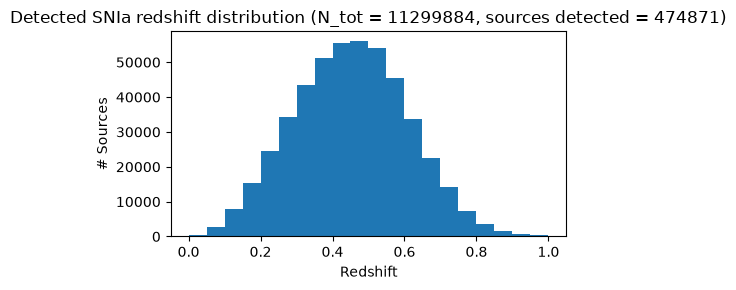

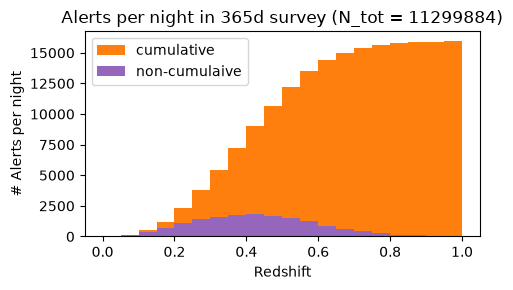

In [28]:
# 1) number of detected sources per z-bin
N_tot = len(combined)

plt.figure(figsize=(5, 3))
plt.hist(detected["z"], bins=np.arange(0, 1.01, 0.05), color="tab:blue")
plt.xlabel("Redshift")
plt.ylabel("# Sources")
plt.title(f"Detected SNIa redshift distribution (N_tot = {N_tot}, sources detected = {len(detected)})")
plt.tight_layout()
plt.show()

# 2) alerts per night per z-bin
plt.figure(figsize=(5, 3))
plt.hist(
    detected["z"],
    cumulative=True,
    bins=np.arange(0, 1.01, 0.05),
    weights=detected["n_detections"].values / 365.0,
    color="tab:orange",
    label = 'cumulative'
)
plt.hist(
    detected["z"],
    cumulative=False,
    bins=np.arange(0, 1.01, 0.05),
    weights=detected["n_detections"].values / 365.0,
    color="tab:purple",
    label = 'non-cumulaive'
)

plt.xlabel("Redshift")
plt.ylabel("# Alerts per night")
plt.title(f"Alerts per night in 365d survey (N_tot = {N_tot})")
plt.legend()
plt.tight_layout()
plt.show()

Text(0.5, 1.0, '# n sources over 365 days')

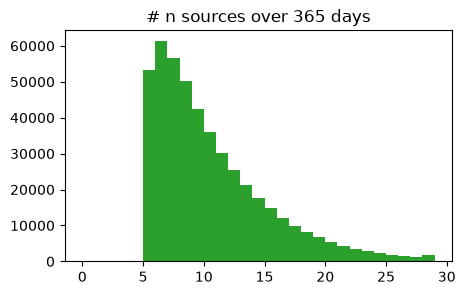

In [29]:
plt.figure(figsize = (5,3))
plt.hist(detected['n_detections'], bins = np.arange(0, 30, 1), color="tab:green")
plt.title('# n sources over 365 days')

In [30]:
from astropy import units as u
from params import p_cosmology

import astropy.cosmology as acosmo
cosmo = acosmo.LambdaCDM(H0=p_cosmology['h0']* u.km / u.s / u.Mpc, 
                         Om0=p_cosmology['omega_M'],
                        Ode0=p_cosmology['omega_L'])

In [31]:
dVdz = cosmo.comoving_volume(np.arange(0, 1.01, 0.1))
dVdz

<Quantity [0.00000000e+00, 3.42681741e+08, 2.53951701e+09, 7.91794120e+09,
           1.73051656e+10, 3.11256781e+10, 4.94999116e+10, 7.23327651e+10,
           9.93866712e+10, 1.30338209e+11, 1.64819739e+11] Mpc3>

In [32]:
shell_volumes = np.diff(cosmo.comoving_volume(np.arange(0, 1.01, 0.05))).to(u.Mpc**3)
# shell_volumes_diff = (cosmo.differential_comoving_volume(np.arange(0, 1.01, 0.05))*4*np.pi*u.sr).to(u.Mpc**3)
# shell_volumes / shell_volumes_diff

In [33]:
cosmo.comoving_volume(1)

<Quantity 1.64819739e+11 Mpc3>

Text(0.5, 1.0, 'Comoving volume per redshift shell (zwidth = 0.05)')

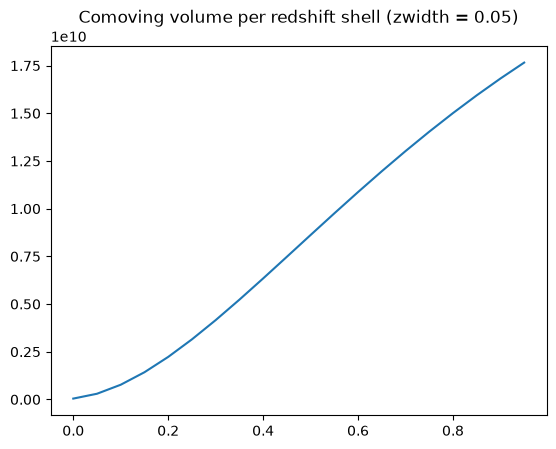

In [34]:
plt.plot(np.arange(0, 1, 0.05), shell_volumes)
plt.title('Comoving volume per redshift shell (zwidth = 0.05)')

The formula can be taken from Petrecca & Botticelli et al 2024, who considered much more biases and selection/filtering criteria.

Direct quote from page 10 of:
https://www.aanda.org/articles/aa/full_html/2024/06/aa49012-23/aa49012-23.html \
"We now show how we measured the effect of the different
biases on the derived SN rates. To this aim, we computed the
SN Ia volumetric rate for each sample as
$$
r_{\mathrm{SN} \mathrm{Ia}}(z)=\frac{(1+z)}{V(z)} \frac{N_{\mathrm{SN}}(z)}{T \epsilon(z)}
$$

where $N_{SN}(z)$ is the number of SNe in each redshift bin for the
selected sample, $T$ is the observing window, $(1 + z)$ corrects
for time dilation, $\epsilon(z)$ is the SN Ia recovery efficiency defined in
Table 2, and $V(z)$ is the comoving volume for the given redshift
bin..."


In [35]:
T_window = (465/365) #in yr, since our volumetric rates are in yr. Petrecca & Botticella et al.
Rz_bin_counts = n_sources.values/shell_volumes / T_window #Mpc^-3 yr^-1
Rz_bin_counts_all = n_sources_all.values/shell_volumes / T_window #Mpc^-3 yr^-1
Rz_bin_counts[5:7], Rz_bin_counts_all[5:7]

(<Quantity [8.57518942e-06, 8.21188995e-06] 1 / Mpc3>,
 <Quantity [3.44291213e-05, 3.68758168e-05] 1 / Mpc3>)

In [36]:
n_sources.index

CategoricalIndex([[0.0, 0.05), [0.05, 0.1), [0.1, 0.15), [0.15, 0.2),
                  [0.2, 0.25), [0.25, 0.3), [0.3, 0.35), [0.35, 0.4),
                  [0.4, 0.45), [0.45, 0.5), [0.5, 0.55), [0.55, 0.6),
                  [0.6, 0.65), [0.65, 0.7), [0.7, 0.75), [0.75, 0.8),
                  [0.8, 0.85), [0.85, 0.9), [0.9, 0.95), [0.95, 1.0)],
                 categories=[[0.0, 0.05), [0.05, 0.1), [0.1, 0.15), [0.15, 0.2), ..., [0.8, 0.85), [0.85, 0.9), [0.9, 0.95), [0.95, 1.0)], ordered=True, dtype='category', name='z_bin')

20 21
20


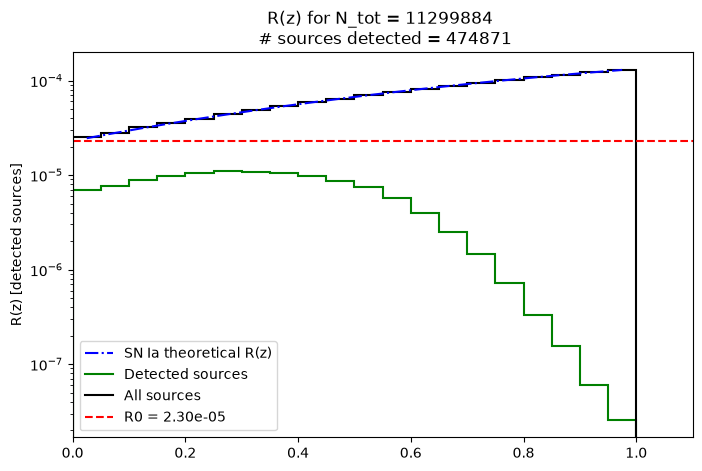

In [37]:
# zmin here is 1e-4
plt.figure(figsize = (8,5))
from transient_rates import R_SFR
# z_range = np.linspace(0, 10, 1000)
intervals = n_sources.index
z_edges = np.array([intervals[0].left] + [interval.right for interval in intervals])
z_mids = (z_edges[:-1] + z_edges[1:]) / 2
print(len(z_mids), len(z_edges))

R_z = R_SFR(z_mids, R0=p_cosmology['R0']['SN Ia'].to(u.Mpc**-3 / u.yr))# / (1+z_edges)

plt.plot(z_mids, R_z, color='blue', linestyle = '-.', label='SN Ia theoretical R(z)')
plt.stairs(Rz_bin_counts * (1 + z_mids), z_edges, label='Detected sources', color='green', lw = 1.5)
plt.stairs(Rz_bin_counts_all * (1 + z_mids), z_edges, label='All sources', color='k', lw = 1.5)
plt.yscale('log')
plt.ylabel('R(z) [detected sources]')
plt.axhline(p_cosmology['R0']['SN Ia'].to(u.Mpc**-3 / u.yr) .value, color='r', linestyle='--', label='R0 = {:.2e}'.format(p_cosmology['R0']['SN Ia'].to(u.Mpc**-3 / u.yr).value))

plt.title(f'R(z) for N_tot = {N_tot} \n # sources detected = {len(detected)}')

# plt.xlim(0.0, 0.05)
print(len(R_z))

plt.legend()
plt.xlim(0, 1.1)

plt.show()
#looks like ther eis a sys diff
# this plot shows that we are indeed getting the rate we expected. Ratio between two gives completeness.
# before we added the x (1+z), we estimated number of transients compared to model by a factor 0.58. which comes from integrating z from 0 to 1

Text(0.5, 1.0, 'SNIa Detection efficiency $\\epsilon$')

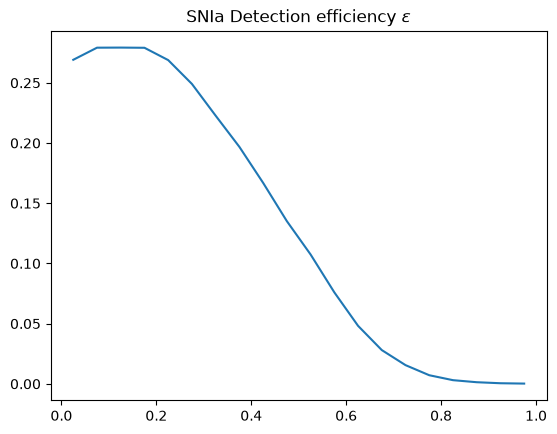

In [57]:
# plot detection efficiency
plt.plot(z_mids, Rz_bin_counts / Rz_bin_counts_all)
plt.title('SNIa Detection efficiency $\\epsilon$')

In [39]:
# find the expected ratio of generated R(z) vs theoretical R(z)
# ratio < 1 due to generated R(z) considering time dilation (observer frame) while theoretical is source frame

z_edges = np.linspace(p_cosmology["z_min"],1.0,100001)

z_grid = 0.5 * (z_edges[:-1] + z_edges[1:])

shell_volumes = np.diff(
    cosmo.comoving_volume(z_edges)
).to(u.Mpc**3)

R = R_SFR(z_grid, R0=1)

ratio_expected = (
    np.sum(R / (1 + z_grid) * shell_volumes)
    / np.sum(R * shell_volumes)
)

print(ratio_expected)

0.5748523810964798


In [40]:
intervals = n_sources.index
z_mid = (z_edges[:-1] + z_edges[1:]) / 2

In [55]:
intervals

CategoricalIndex([[0.0, 0.05), [0.05, 0.1), [0.1, 0.15), [0.15, 0.2),
                  [0.2, 0.25), [0.25, 0.3), [0.3, 0.35), [0.35, 0.4),
                  [0.4, 0.45), [0.45, 0.5), [0.5, 0.55), [0.55, 0.6),
                  [0.6, 0.65), [0.65, 0.7), [0.7, 0.75), [0.75, 0.8),
                  [0.8, 0.85), [0.85, 0.9), [0.9, 0.95), [0.95, 1.0)],
                 categories=[[0.0, 0.05), [0.05, 0.1), [0.1, 0.15), [0.15, 0.2), ..., [0.8, 0.85), [0.85, 0.9), [0.9, 0.95), [0.95, 1.0)], ordered=True, dtype='category', name='z_bin')

20 20 100001 20


Text(0.5, 1.0, 'Rz_bin_counts_all * (1+z_mids)/ R_z  for N_tot = 11299884 \n # sources detected = 474871')

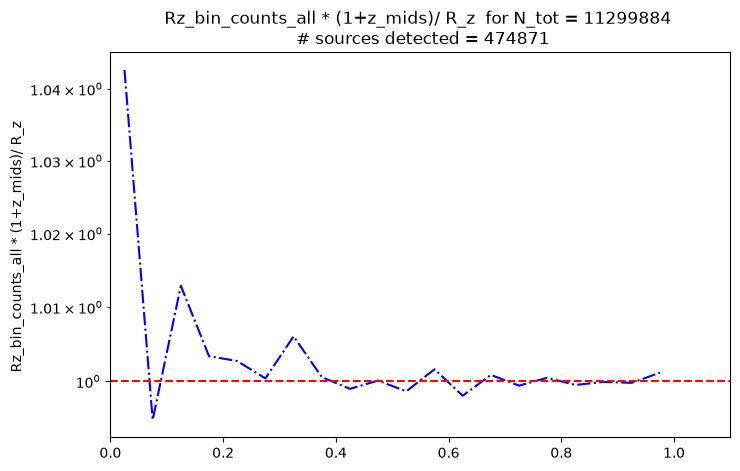

In [41]:
plt.figure(figsize = (8,5))
from transient_rates import R_SFR
# intervals = n_sources.index
# z_edges = .np.array([intervals[0].left] + [interval.right for interval in intervals])
R_z = R_SFR(z_mids , R0=p_cosmology['R0']['SN Ia'].to(u.Mpc**-3 / u.yr))
print(len(R_z), len(z_mids), len(z_edges), len(Rz_bin_counts_all))

plt.plot(z_mids, Rz_bin_counts_all * (1+z_mids)/ R_z , color='blue', linestyle = '-.', label='SN Ia theoretical R(z)')

plt.yscale('log')
plt.ylabel('Rz_bin_counts_all * (1+z_mids)/ R_z ')
plt.axhline(1, color='r', linestyle='--', label='R0 = {:.2e}'.format(p_cosmology['R0']['SN Ia'].to(u.Mpc**-3 / u.yr).value))
plt.xlim(0, 1.1)
plt.title(f'Rz_bin_counts_all * (1+z_mids)/ R_z  for N_tot = {N_tot} \n # sources detected = {len(detected)}')

# 10 years: we will avg out random sampling issues.

In [42]:
print('alerts per night:', detected['n_detections'].sum() / 365) # n_alerts per night.

alerts per night: 15956.501369863014


Text(0.5, 1.0, 'All sources at each redshift bin')

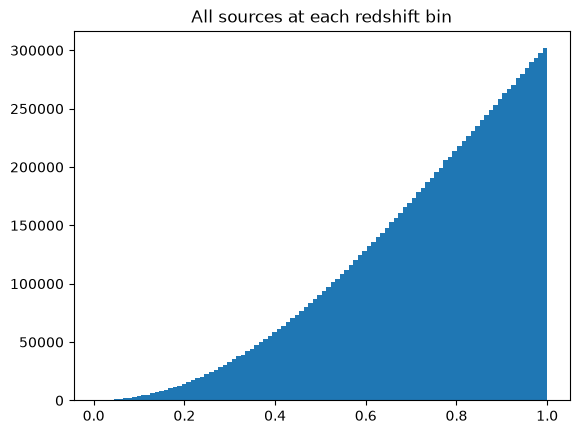

In [56]:
plt.hist(all_sources['z'], bins = 100)
plt.title('All sources at each redshift bin')

In [45]:
print(f"Total alerts per night: {detected['n_detections'].sum() / 365}")

Total alerts per night: 15956.501369863014


In [46]:
len(detected) / 365, len(combined)/365

(1301.0164383561644, 30958.58630136986)

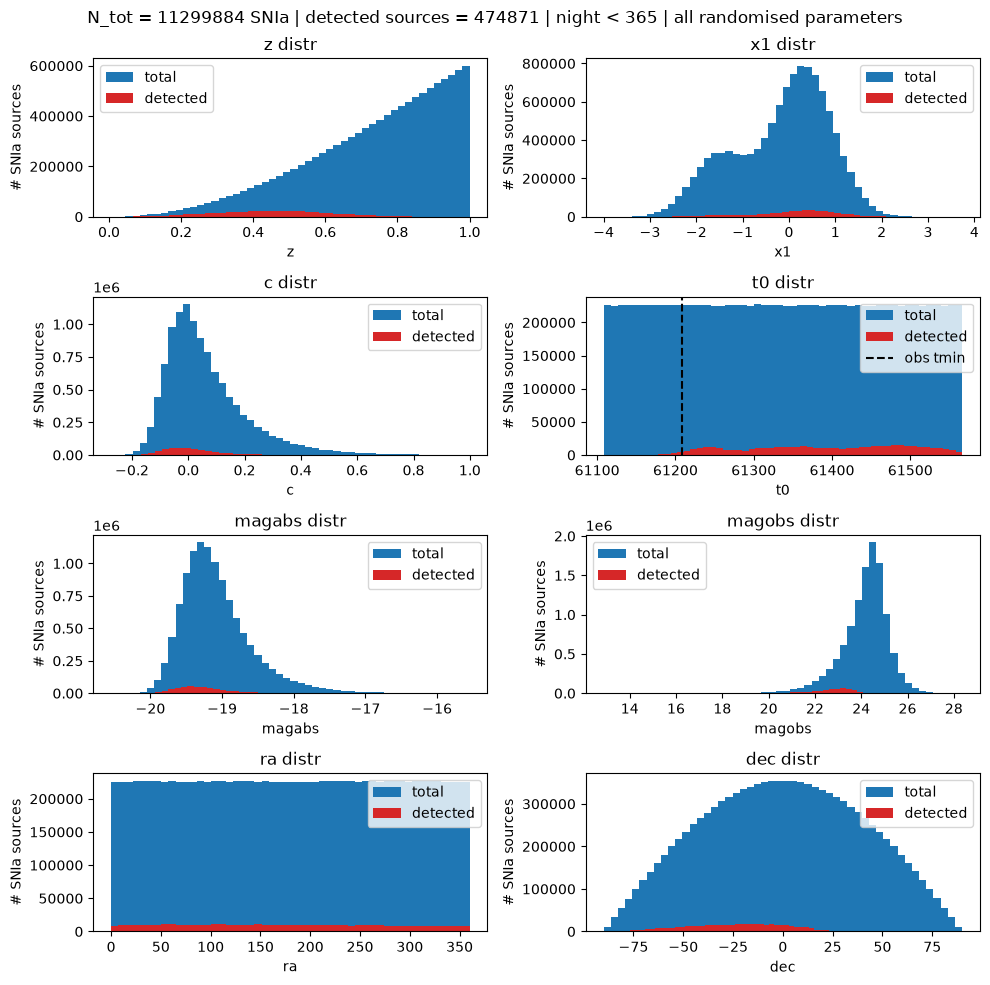

In [ ]:
#perhaps this way, you don't need to specify bins?

detected_models = combined[combined['detected'] == True]

params = ['z', 'x1', 'c', 't0', 'magabs', 'magobs', 'ra', 'dec']

fig, axs = plt.subplots(4, 2, figsize=(10, 10))

for ax, param in zip(axs.flat, params):
    ax.hist(combined[param], bins=50, color='tab:blue', alpha=1.0, label='total')
    ax.hist(detected_models[param], bins=50, color='tab:red', alpha=1.0, label='detected')

    if param == 't0':
        ax.axvline(tmin, color='k', linestyle='--', label='obs tmin')

    ax.set_xlabel(param)
    ax.set_ylabel("# SNIa sources")
    ax.set_title(f"{param} distr")
    ax.legend()

# Hide unused subplot
for ax in axs.flat[len(params):]:
    ax.set_visible(False)

plt.suptitle(
    f'N_tot = {N_tot} SNIa | detected sources = {len(detected_models)} | night < 365 | all randomised parameters'
)
plt.tight_layout()
plt.show()

### Checking that SNIa population aligns with observations
#### I was not able to find any agreement when doing this, but I did not read deeply into this.

Redshift evolution of the underlying type Ia supernova stretch distributions: https://www.aanda.org/articles/aa/pdf/2021/05/aa38447-20.pdf
SNe Ia at higher redshift have a larger stretch (0.34 ± 0.10 at z ∼ 0.65) on average than those at lower redshift (−0.17 ± 0.10 at z ∼ 0.05), suggesting that the underlying stretch distribution evolves with redshift.

In [ ]:
combined_highz = combined[(combined['z'] > 0.62) & (combined['z'] <= 0.68)]
combined_lowz = combined[(combined['z'] > 0.02) & (combined['z'] <= 0.08)]
combined_highz['x1'].describe(), combined_lowz['x1'].describe()

In [ ]:
plt.hist(combined_lowz['x1'], histtype='step', label='Low z', color='tab:blue', bins=30)
plt.hist(combined_highz['x1'], histtype='step', label='High z', color='tab:orange', bins=30)
plt.xlabel('x1')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [ ]:
combined['z'].max()